# Jornada de IA
## Introdução a Algoritmos de Machine Learning & IA generativa

**Time:** Motiva
**Instrutor:** Rafael Monteiro (rafael.a.monteiro.math@gmail.com)

___ 

# 2. Lab 2 - Clusterização


Clusterização é uma técnica que visa entender padrões na distribuição de valores de uma população. Enquanto anteriormente tinhamos atributos X e rótulos Y para todos os indivíduos, agora é diferente: só possuímos dados X, não há mais rótulos. 


## 2.1  K-means


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.animation import FuncAnimation
from sklearn.datasets import make_blobs
from IPython.display import HTML

IMAGES_PATH = "images"
plt.rc("font", size=14)
plt.rc("axes", labelsize=14, titlesize=14)
plt.rc("legend", fontsize=14)
plt.rc("xtick", labelsize=10)
plt.rc("ytick", labelsize=10)

# ── Data ──────────────────────────────────────────────────────────────────────
np.random.seed(0)


X, y = make_blobs(
    n_samples=300,
    n_features=2,
    centers=[(-10, 0), (10, 0), (0, 7)],
    cluster_std=1.0,
    center_box=(0, 4),
    shuffle=True,
    random_state=None,
    return_centers=False,
)
K = 3
COLORS = ["#e74c3c", "#2ecc71", "#3498db"]
MAX_ITER = 12

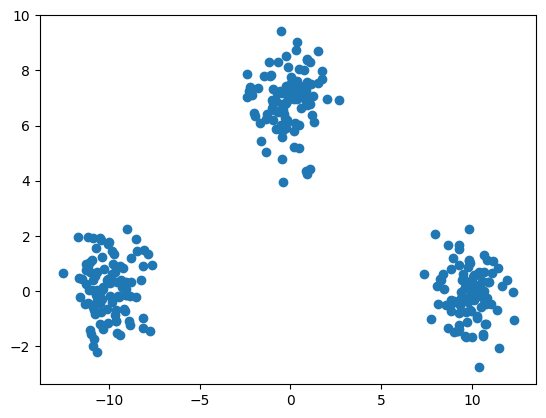

In [4]:
plt.scatter(
    X[:, 0],
    X[:, 1],
)  # c=y)
plt.show()

In [5]:
# ── Manual K-Means (step-by-step) ─────────────────────────────────────────────
def run_kmeans_steps(X, k, max_iter, seed=42):
    rng = np.random.default_rng(seed)
    centroids = 8 * np.ones_like(
        X[rng.choice(len(X), k, replace=False)]
    ) + 0.3 * np.random.normal(size=(k, 2))
    history = []  # list of (centroids, labels) per iteration
    for _ in range(max_iter):
        # Assign step0, r0, r0, r
        dists = np.linalg.norm(X[:, None, :] - centroids[None, :, :], axis=2)
        labels = dists.argmin(axis=1)
        history.append((centroids.copy(), labels.copy()))
        # Update step
        new_centroids = np.array(
            [
                X[labels == j].mean(axis=0) if (labels == j).any() else centroids[j]
                for j in range(k)
            ]
        )
        if np.allclose(new_centroids, centroids):
            break
        centroids = new_centroids
    return history


steps = run_kmeans_steps(X, K, MAX_ITER)

In [6]:
# ── Animation ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))


def draw_frame(i):
    ax.clear()
    centroids, labels = steps[i]

    for j in range(K):
        mask = labels == j
        ax.scatter(
            X[mask, 0], X[mask, 1], c=COLORS[j], alpha=0.55, s=25, edgecolors="none"
        )
        ax.scatter(
            *centroids[j],
            c=COLORS[j],
            s=220,
            marker="*",
            edgecolors="black",
            linewidths=0.8,
            zorder=5,
        )

    ax.set_title(f"K-Means  —  iteration {i + 1} / {len(steps)}", fontsize=13)
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")
    legend = [mpatches.Patch(color=COLORS[j], label=f"Cluster {j+1}") for j in range(K)]
    ax.legend(handles=legend, loc="upper right", fontsize=8)
    ax.set_xlim(X[:, 0].min() - 3, X[:, 0].max() + 3)
    ax.set_ylim(X[:, 1].min() - 3, X[:, 1].max() + 3)


ani = FuncAnimation(fig, draw_frame, frames=len(steps), interval=1200, repeat=True)
plt.close()

HTML(ani.to_jshtml())

Existe no entanto um aspecto não muito "convincente" no que fizemos acima:
1. Logo de cara, já "chutamos" o número de centroides que o modelo vai utilizar.
2. Mas como podemos chutar corretamente se etivermos em um caso com muitas váriáveis, em dimensão tão alta que não conseguimos visualizar os dados em um gráfico?


O que as pessoas utilizam neste caso é  o que chamam de **elbow method** (`método do cotovelo`, em tradução literal). O que se faz neste caso é a plotagem da inécia do modelo (a inércia é o quadrado da distância de cada grupo de pontos em relação à sua centróide). 

No método do cotovelo, busca-se visualmente pelo número de clusters onde se obteve o maior decaimento na inércia. 


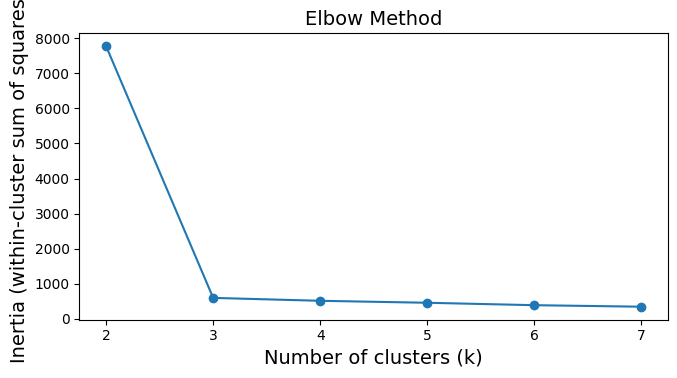

In [7]:
from sklearn.cluster import KMeans

# Elbow method: run KMeans for k = 2 to 5 and plot inertia
inertias = []
k_values = range(2, 8)

for k in k_values:
    km = KMeans(n_clusters=k, random_state=0, n_init="auto")
    km.fit(X)
    inertias.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(list(k_values), inertias, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia (within-cluster sum of squares)")
plt.title("Elbow Method")
plt.xticks(list(k_values))
plt.tight_layout()
plt.show()

No caso acima, o valor ideal no número de clusters seria 3.

## 2.2  K-means é um bom método, mas não funciona para tudo - DBSCAN

Vamos colera um conjunto de dados um pouco mais desafiador. 

In [8]:
from sklearn.datasets import make_moons

X, y = make_moons(n_samples=100, shuffle=True, noise=0.08, random_state=None)

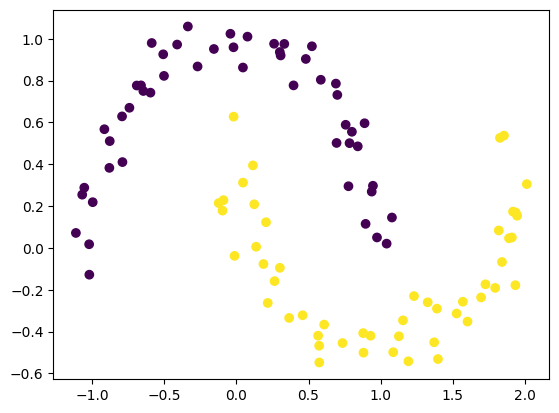

In [9]:
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.show()

### 2.2.1 - Exercício

Rode o método Kmeans com 2 centróides no conjunto de dados acima.

O resultado é satisfatório?

In [10]:
from sklearn.cluster import KMeans

In [11]:
kmeans = KMeans(
    n_clusters=2,
    random_state=0,
    n_init="auto",
)

kmeans.fit(X)
y_pred = kmeans.labels_

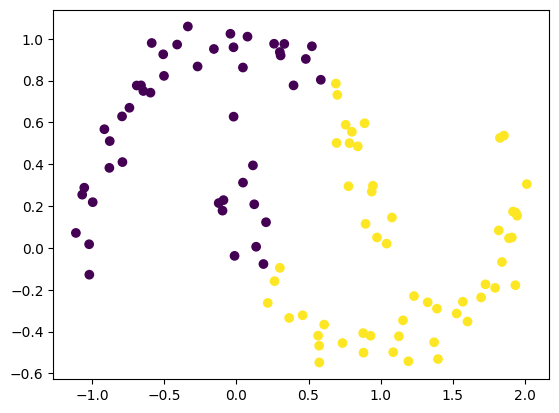

In [12]:
plt.scatter(X[:, 0], X[:, 1], c=y_pred)
plt.show()

Há outros métodos muito interessantes e mais efetivos para alguns tipos de dados. Por exemplo, o método DBSCAN. 

Este método no entanto possui um parâmetro - $\epsilon$ - que precisa ser ajustado. **Ele indica o grau de proximidade entre pontos para que os mesmos sejam considerados dentro de um mesmo cluster.** 

Perguntas quanto ao parâmetro $\epsilon$:
* O que acontece se tomarmos $\epsilon = 0$?
* O que acontece se tomarmos $\epsilon = \infty$?

In [13]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.3, min_samples=5)
dbscan.fit(X)

,eps,0.3
,min_samples,5
,metric,'euclidean'
,metric_params,None
,algorithm,'auto'
,leaf_size,30
,p,None
,n_jobs,None


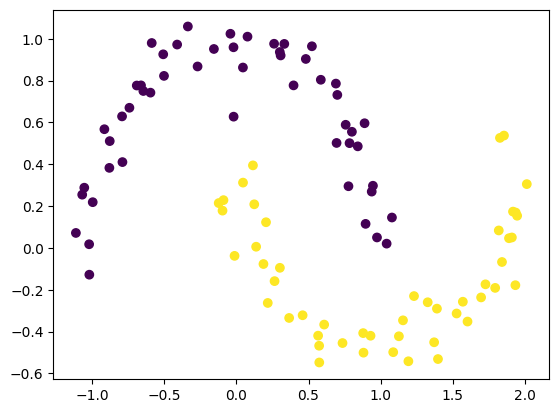

In [14]:
y_pred = dbscan.labels_
plt.scatter(X[:, 0], X[:, 1], c=y_pred)
plt.show()

## 2.2.2 Exercicios

Refaça o exercício acima utilizando o conjunto de dados [make circles](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_circles.html). Qual método funciona melhor?

## 2.3 "Curse of dimensionality"


No que segue, vamos calcular o quanto do volume de uma caixa de 1 m de lado se encontra próximo à superfície. Digamos, se encontra a uma distância de 5 cm da sua superfície. 

* Em dimensão 1 isso é fácil:

fração próxima à superfície:  $$10/100 = .10   \quad(\text{ou seja}, 10\%)$$

* Em dimensão 2 isso também é fácil:

fração próxima à superfície:  $$(1 - \frac{90*90}{100*100}) = .19   \quad(\text{ou seja}, 19\%)$$


E em dimensão N?



Plote esse gráfico. O que você pode concluir a partir dele?